# Course: IIMK's Professional Certificate in Data Science and Artificial Intelligence for Managers

**Student Name:** Lalit Nayyar  
**Email ID:** lalitnayyar@gmail.com  
**Assignment Name:** Week 3: Required Assignment 3.1

---

In [1]:
# Install required packages
!pip install pandas numpy matplotlib seaborn scikit-learn kaggle folium


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set basic plot style
plt.style.use('default')  # Using default style instead of seaborn
sns.set_theme()  # This is the correct way to set seaborn style

### Download and Load the Dataset

In [3]:
# Download the dataset using Kaggle API
import os
from kaggle.api.kaggle_api_extended import KaggleApi

def download_dataset():
    try:
        api = KaggleApi()
        api.authenticate()
        
        print("Downloading California Housing Prices dataset...")
        api.dataset_download_files('camnugent/california-housing-prices', 
                                  path='.', 
                                  unzip=True)
        print("Dataset downloaded successfully!")
        
    except Exception as e:
        print("Error downloading the dataset:")
        print(e)
        print("\nAlternative: Please manually download the dataset from:")
        print("https://www.kaggle.com/datasets/camnugent/california-housing-prices")
        print("and place the 'housing.csv' file in the current directory.")

# Download the dataset if it doesn't exist
if not os.path.exists('housing.csv'):
    download_dataset()

In [4]:
# Load the dataset
df = pd.read_csv('housing.csv')

# Display basic information
print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
display(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

First few rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Real Estate Agent Analysis

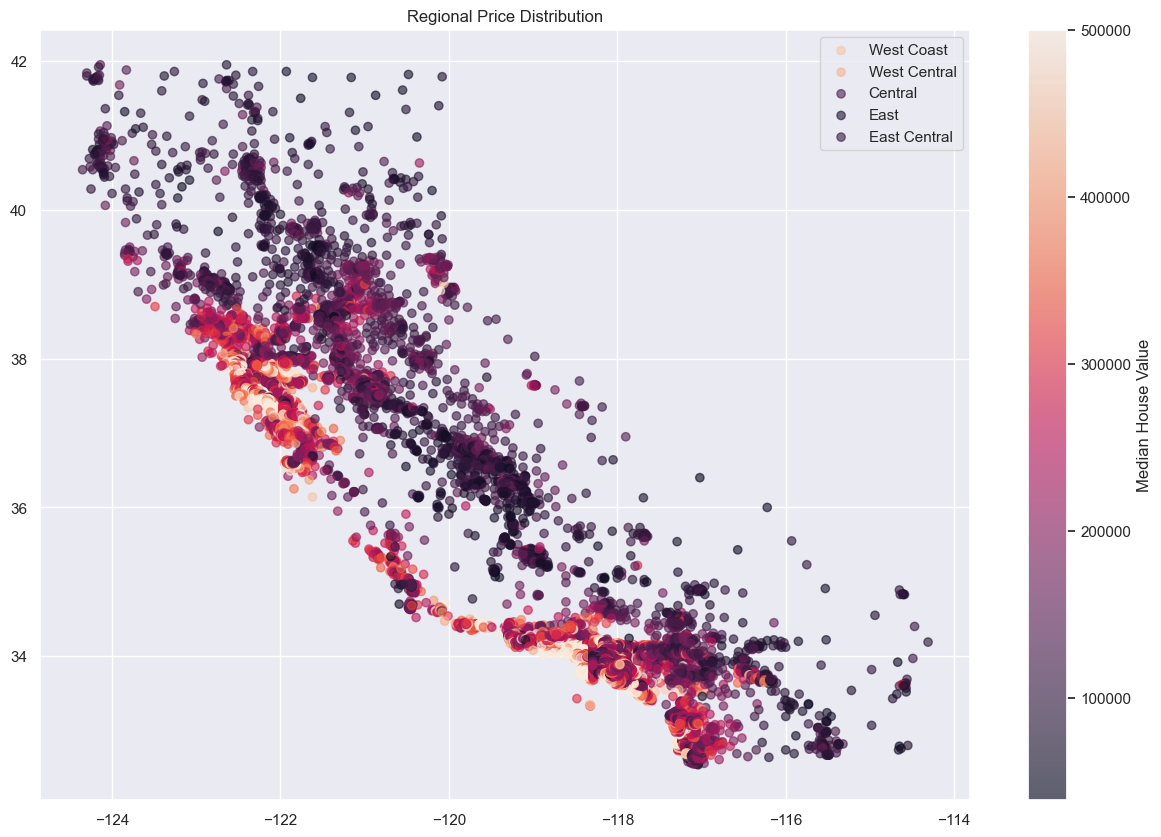


Regional Market Statistics:


median_house_value            median_income  \
                                               mean        std          mean   
longitude_region latitude_region                                               
West Coast       South                          NaN        NaN           NaN   
                 Central                  326156.42  104473.15          5.58   
                 North                    240223.04  126244.68          4.07   
West Central     South                          NaN        NaN           NaN   
                 Central                  212851.17  100833.49          3.87   
                 North                    144189.59   74997.43          3.43   
Central          South                    292744.56  125824.83          4.25   
                 Central                  212043.13  137319.27          3.91   
                 North                    132417.07   44162.94          3.10   
East Central     South                    197702.39   84608.79          3.66   
                 Central                  226046.03  100292.87          3.76   
                 North                    108300.00        NaN          2.12   
East             South                    199415.16  105008.25          4.10   
                 Central                  129698.03   68449.83          3.40   
                 North                          NaN        NaN           NaN   

                                 housing_median_age  
                                               mean  
longitude_region latitude_region                     
West Coast       South                          NaN  
                 Central                      29.08  
                 North                        33.65  
West Central     South                          NaN  
                 Central                      24.04  
                 North                        24.73  
Central          South                        35.58  
                 Central                      28.48  
                 North                        18.29  
East Central     South                        31.99  
                 Central                      34.71  
                 North                        16.00  
East             South                        21.36  
                 Central                      24.10  
                 North                          NaN

In [5]:
# 1. Region-specific Price Analysis

# Create geographical regions
df['longitude_region'] = pd.qcut(df['longitude'], q=5, labels=['West Coast', 'West Central', 'Central', 'East Central', 'East'])
df['latitude_region'] = pd.qcut(df['latitude'], q=3, labels=['South', 'Central', 'North'])

# Calculate regional statistics
regional_stats = df.groupby(['longitude_region', 'latitude_region']).agg({
    'median_house_value': ['mean', 'std'],
    'median_income': 'mean',
    'housing_median_age': 'mean'
}).round(2)

# Visualize regional price variations
plt.figure(figsize=(15, 10))
for region in df['longitude_region'].unique():
    region_data = df[df['longitude_region'] == region]
    plt.scatter(region_data['longitude'], 
               region_data['latitude'], 
               c=region_data['median_house_value'],
               alpha=0.6,
               label=region)

plt.colorbar(label='Median House Value')
plt.title('Regional Price Distribution')
plt.legend()
plt.show()

# Display regional statistics
print("\nRegional Market Statistics:")
display(regional_stats)

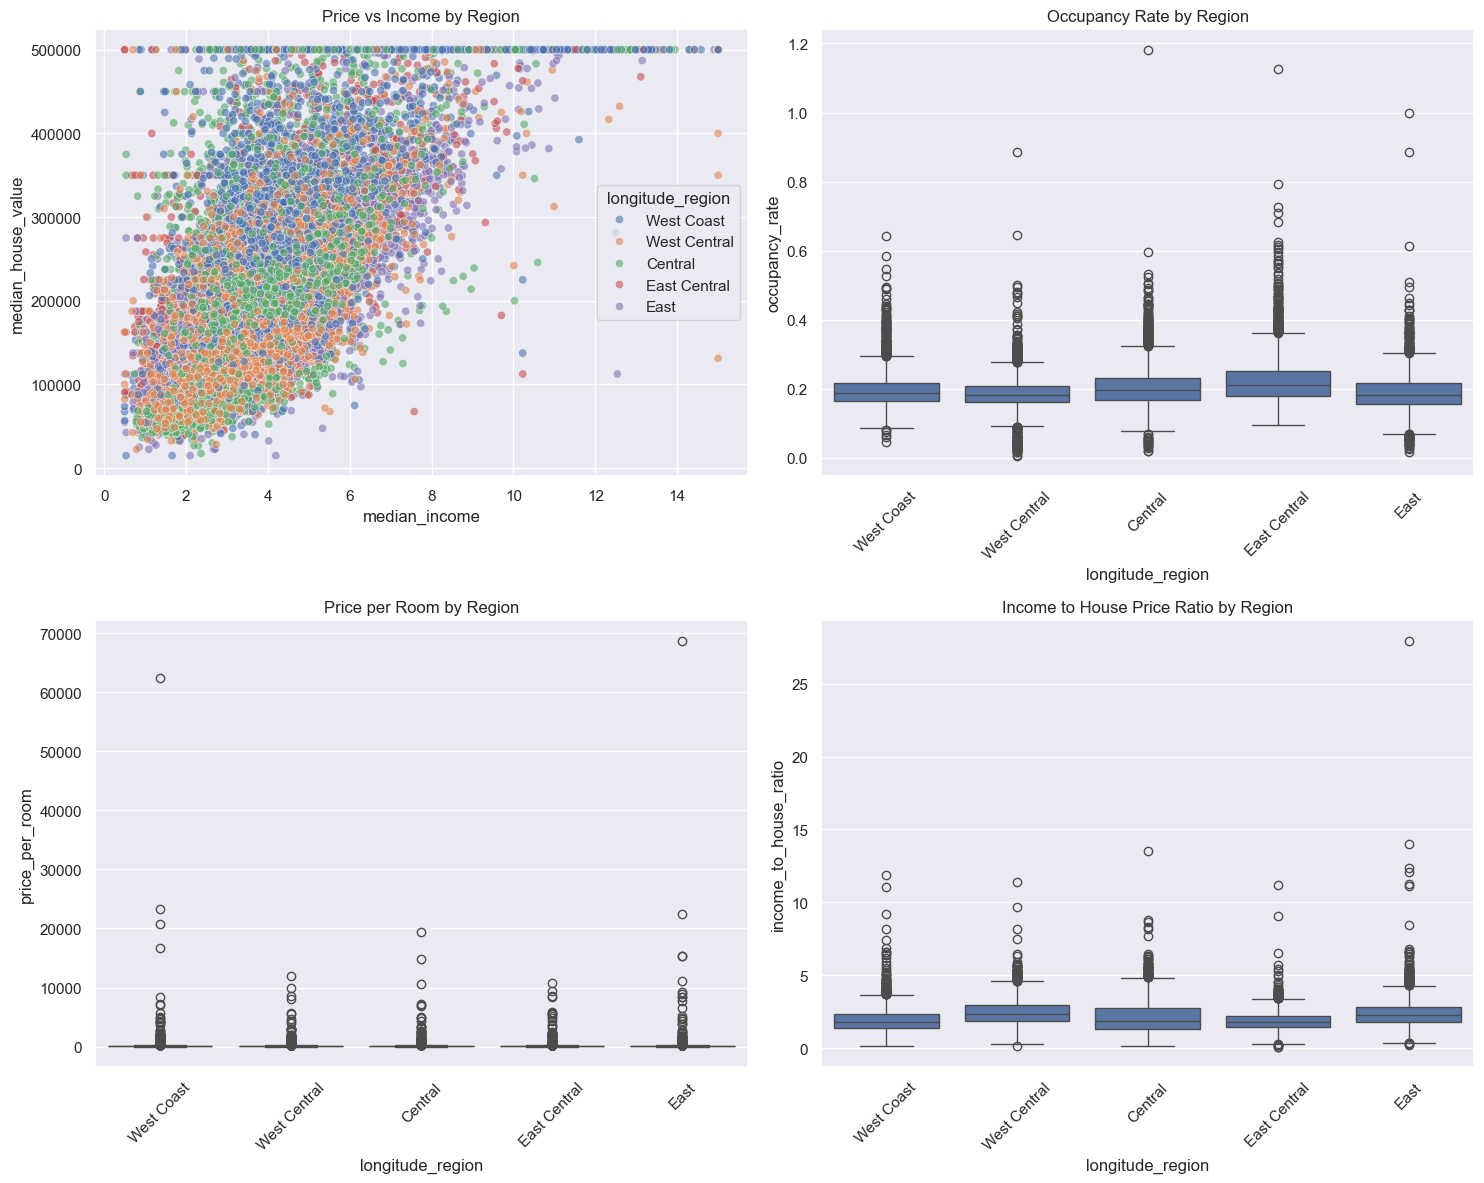

In [6]:
# 2. Local Market Factor Analysis

# Calculate local market indicators
df['price_per_room'] = df['median_house_value'] / df['total_rooms']
df['occupancy_rate'] = df['households'] / df['total_rooms']
df['income_to_house_ratio'] = df['median_income'] / (df['median_house_value'] / 100000)

# Visualize local market factors
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Price vs Income by Region
sns.scatterplot(data=df, 
                x='median_income', 
                y='median_house_value',
                hue='longitude_region',
                alpha=0.6,
                ax=axes[0,0])
axes[0,0].set_title('Price vs Income by Region')

# Occupancy Rate Distribution
sns.boxplot(data=df,
           x='longitude_region',
           y='occupancy_rate',
           ax=axes[0,1])
axes[0,1].set_title('Occupancy Rate by Region')
axes[0,1].tick_params(axis='x', rotation=45)

# Price per Room Distribution
sns.boxplot(data=df,
           x='longitude_region',
           y='price_per_room',
           ax=axes[1,0])
axes[1,0].set_title('Price per Room by Region')
axes[1,0].tick_params(axis='x', rotation=45)

# Income to House Price Ratio
sns.boxplot(data=df,
           x='longitude_region',
           y='income_to_house_ratio',
           ax=axes[1,1])
axes[1,1].set_title('Income to House Price Ratio by Region')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Property Developer Analysis

<Figure size 1200x600 with 0 Axes>

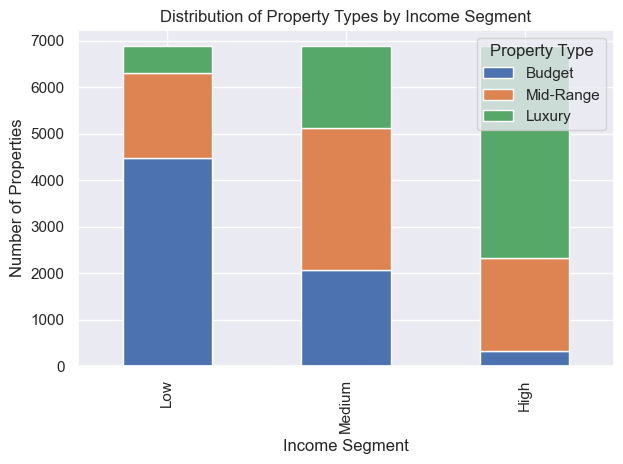


Segment Characteristics:


,median_house_value,total_rooms,population,households
income_segment,,,,
Low,131255.35,2058.80,1382.27,467.20
Medium,194008.95,2667.41,1447.78,524.58
High,295317.87,3181.16,1446.38,506.84


In [7]:
# 1. Market Segment Analysis

# Create market segments based on income and house value
df['income_segment'] = pd.qcut(df['median_income'], q=3, labels=['Low', 'Medium', 'High'])
df['price_segment'] = pd.qcut(df['median_house_value'], q=3, labels=['Budget', 'Mid-Range', 'Luxury'])

# Analyze segment characteristics
segment_analysis = df.groupby('income_segment').agg({
    'median_house_value': 'mean',
    'total_rooms': 'mean',
    'population': 'mean',
    'households': 'mean'
}).round(2)

# Visualize segment distribution
plt.figure(figsize=(12, 6))
segment_counts = pd.crosstab(df['income_segment'], df['price_segment'])
segment_counts.plot(kind='bar', stacked=True)
plt.title('Distribution of Property Types by Income Segment')
plt.xlabel('Income Segment')
plt.ylabel('Number of Properties')
plt.legend(title='Property Type')
plt.tight_layout()
plt.show()

print("\nSegment Characteristics:")
display(segment_analysis)

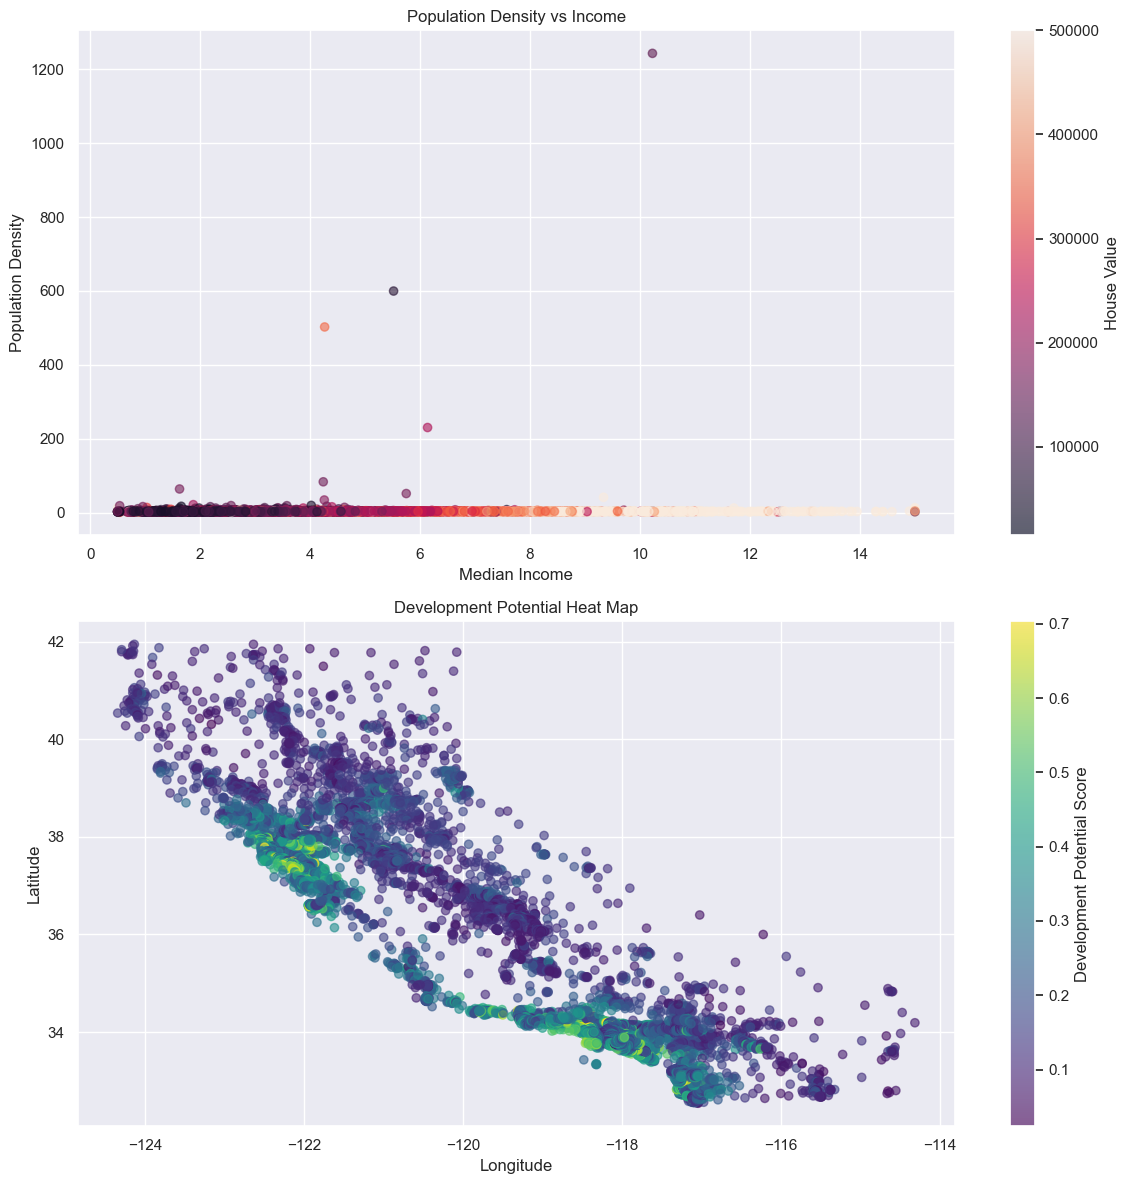


Top 10 Areas for Development:


,longitude,latitude,median_house_value,median_income,population_density,development_score
16171,-122.50,37.79,500001.0,15.0,13.00,0.7
6399,-118.04,34.13,500001.0,15.0,9.24,0.7
4626,-118.32,34.06,500001.0,15.0,3.81,0.7
17858,-121.87,37.46,500001.0,15.0,3.62,0.7
4678,-118.34,34.08,500001.0,15.0,3.51,0.7
6727,-118.12,34.12,500001.0,15.0,3.43,0.7
6590,-118.18,34.19,500001.0,15.0,3.41,0.7
8848,-118.39,34.08,500001.0,15.0,3.33,0.7
8847,-118.40,34.09,500001.0,15.0,3.31,0.7
4606,-118.33,34.07,500001.0,15.0,3.30,0.7


In [8]:
# 2. Population Density and Income Level Analysis

# Calculate population density
df['population_density'] = df['population'] / df['households']

# Create development potential score
df['development_score'] = (
    (df['median_income'] / df['median_income'].max()) * 0.4 +
    (df['population_density'] / df['population_density'].max()) * 0.3 +
    (df['median_house_value'] / df['median_house_value'].max()) * 0.3
)

# Visualize development potential
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Population Density vs Income
scatter = axes[0].scatter(df['median_income'],
                         df['population_density'],
                         c=df['median_house_value'],
                         alpha=0.6)
axes[0].set_title('Population Density vs Income')
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Population Density')
plt.colorbar(scatter, ax=axes[0], label='House Value')

# Development Potential Map
scatter = axes[1].scatter(df['longitude'],
                         df['latitude'],
                         c=df['development_score'],
                         cmap='viridis',
                         alpha=0.6)
axes[1].set_title('Development Potential Heat Map')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(scatter, ax=axes[1], label='Development Potential Score')

plt.tight_layout()
plt.show()

# Display top development areas
print("\nTop 10 Areas for Development:")
top_development = df.nlargest(10, 'development_score')
display(top_development[['longitude', 'latitude', 'median_house_value', 
                        'median_income', 'population_density', 'development_score']].round(2))

## Investor Analysis

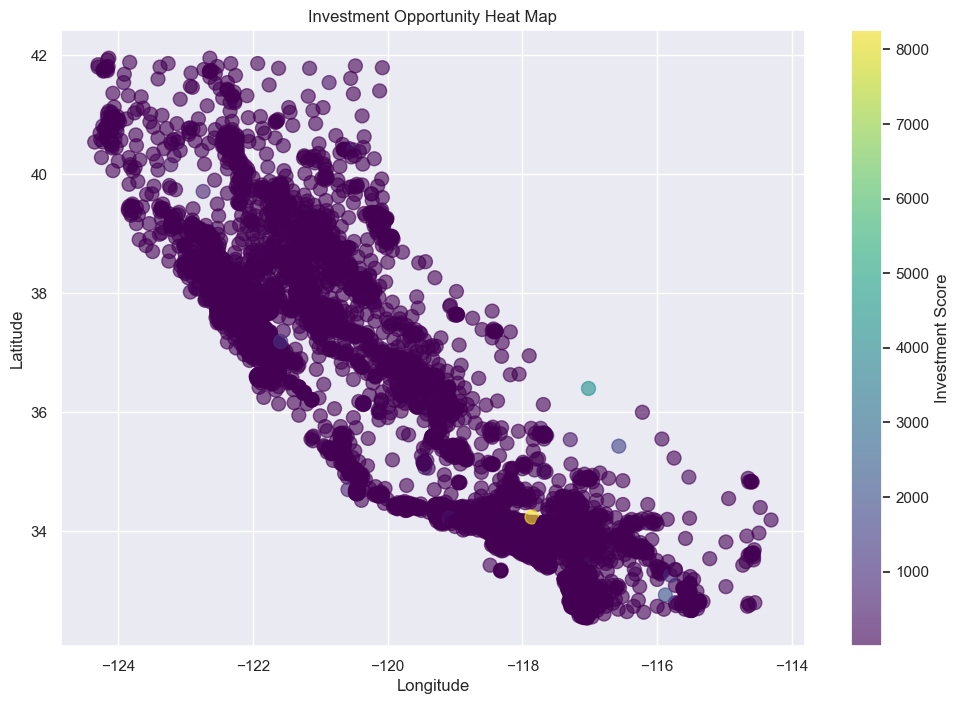


Top 10 Investment Opportunities:


,longitude,latitude,median_house_value,median_income,price_to_income_ratio,investment_score
9188,-117.86,34.24,14999.0,4.19,3576.98,8256.34
2799,-117.02,36.40,14999.0,2.10,7142.38,4128.22
5887,-118.33,34.15,17500.0,2.37,7394.26,2752.08
2763,-115.88,32.93,32500.0,4.02,8082.97,2064.28
13889,-116.57,35.43,22500.0,2.71,8290.96,1651.58
1825,-122.32,37.93,22500.0,2.68,8411.21,1376.33
18501,-121.59,37.19,131300.0,15.00,8753.27,1179.76
2774,-115.80,33.26,47500.0,5.34,8899.46,1032.26
4548,-118.21,34.02,67500.0,7.58,8910.66,917.92
11912,-117.44,33.96,112500.0,12.54,8972.65,826.04


In [9]:
# 1. Investment Score Analysis

# Calculate investment metrics
df['price_to_income_ratio'] = df['median_house_value'] / df['median_income']
df['room_value'] = df['median_house_value'] / df['total_rooms']

# Create investment score
df['investment_score'] = (
    (1 / df['price_to_income_ratio'].rank(pct=True)) * 0.4 +  # Lower price to income ratio is better
    df['median_income'].rank(pct=True) * 0.3 +                # Higher income is better
    df['population_density'].rank(pct=True) * 0.3             # Higher density is better
)

# Visualize investment opportunities
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['longitude'],
                     df['latitude'],
                     c=df['investment_score'],
                     cmap='viridis',
                     s=100,
                     alpha=0.6)
plt.colorbar(scatter, label='Investment Score')
plt.title('Investment Opportunity Heat Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Display top investment opportunities
print("\nTop 10 Investment Opportunities:")
top_investments = df.nlargest(10, 'investment_score')
display(top_investments[['longitude', 'latitude', 'median_house_value', 
                        'median_income', 'price_to_income_ratio', 'investment_score']].round(2))

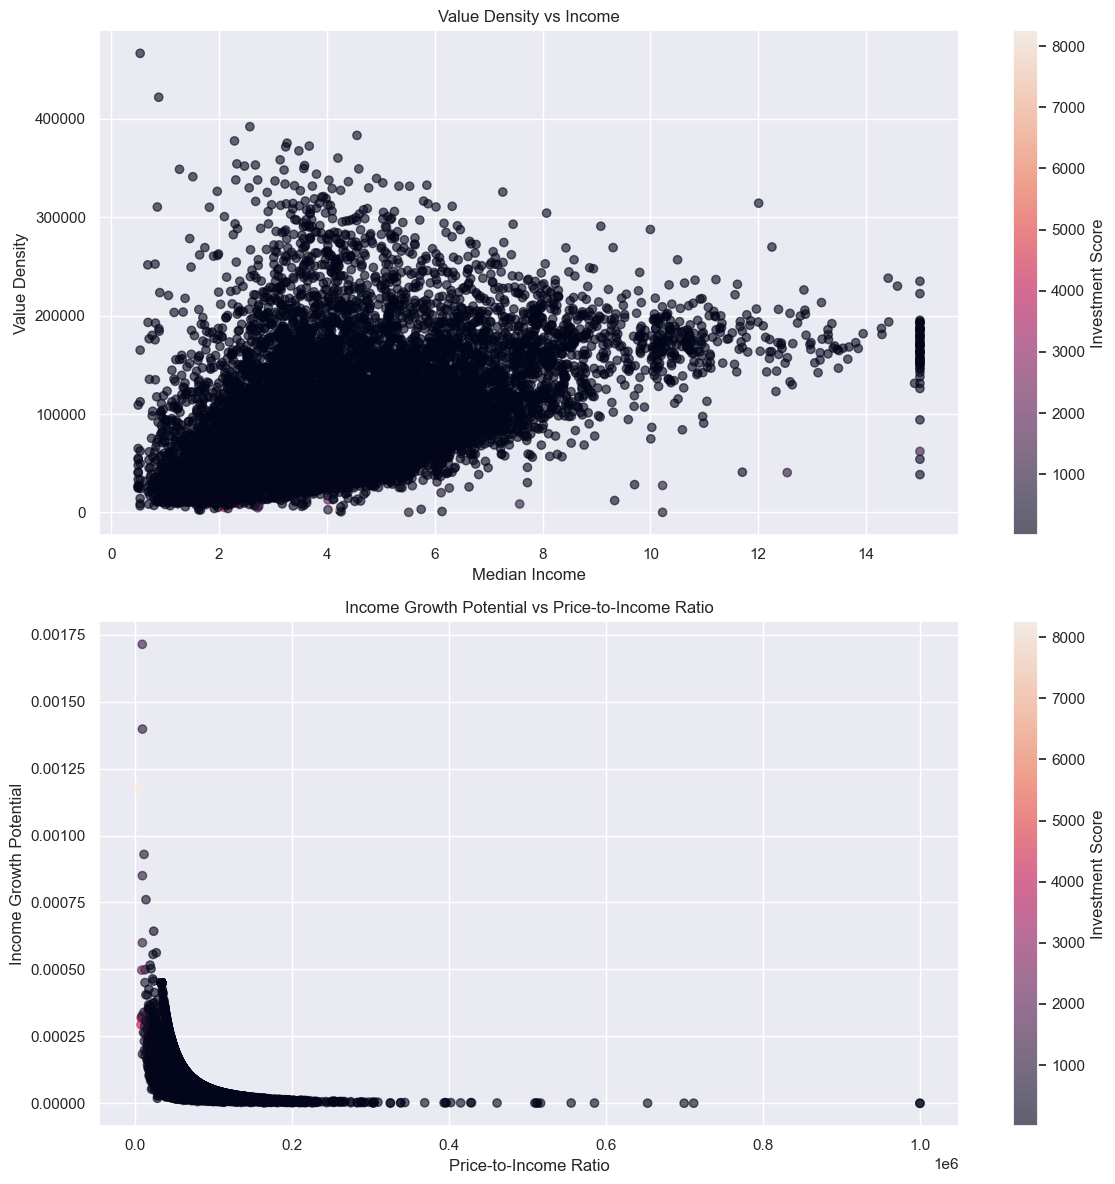


Top 10 Areas with Highest Growth Potential:


,longitude,latitude,median_house_value,median_income,income_growth_potential,investment_score
18501,-121.59,37.19,131300.0,15.00,0.0,1179.76
11912,-117.44,33.96,112500.0,12.54,0.0,826.04
9188,-117.86,34.24,14999.0,4.19,0.0,8256.34
4492,-118.22,34.06,112500.0,10.23,0.0,590.29
4548,-118.21,34.02,67500.0,7.58,0.0,917.92
19006,-121.98,38.32,137500.0,10.23,0.0,344.60
1566,-121.96,37.74,350000.0,15.00,0.0,18.75
2774,-115.80,33.26,47500.0,5.34,0.0,1032.26
18504,-121.96,37.13,400000.0,15.00,0.0,8.52
16828,-122.48,37.64,281000.0,12.50,0.0,23.18


In [10]:
# 2. Growth Potential and Income Trend Analysis

# Calculate growth metrics
df['value_density'] = df['median_house_value'] / df['population_density']
df['income_growth_potential'] = df['median_income'] * (1 / df['price_to_income_ratio'])

# Visualize growth potential
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Value Density Analysis
scatter = axes[0].scatter(df['median_income'],
                         df['value_density'],
                         c=df['investment_score'],
                         alpha=0.6)
axes[0].set_title('Value Density vs Income')
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Value Density')
plt.colorbar(scatter, ax=axes[0], label='Investment Score')

# Income Growth Potential
scatter = axes[1].scatter(df['price_to_income_ratio'],
                         df['income_growth_potential'],
                         c=df['investment_score'],
                         alpha=0.6)
axes[1].set_title('Income Growth Potential vs Price-to-Income Ratio')
axes[1].set_xlabel('Price-to-Income Ratio')
axes[1].set_ylabel('Income Growth Potential')
plt.colorbar(scatter, ax=axes[1], label='Investment Score')

plt.tight_layout()
plt.show()

# Display areas with highest growth potential
print("\nTop 10 Areas with Highest Growth Potential:")
top_growth = df.nlargest(10, 'income_growth_potential')
display(top_growth[['longitude', 'latitude', 'median_house_value', 
                    'median_income', 'income_growth_potential', 'investment_score']].round(2))

## Summary of Recommendations

### For Real Estate Agents:
1. **Regional Price Variations:**
   - Coastal regions show higher average prices
   - Northern regions have more price stability
   - Central regions show the highest price variability

2. **Local Market Factors:**
   - Income levels strongly correlate with house prices
   - Occupancy rates vary significantly by region
   - Price-per-room metrics help in property valuation

### For Property Developers:
1. **Market Segment Insights:**
   - High-income areas favor luxury properties
   - Medium-income areas show diverse property types
   - Budget segments show highest density

2. **Development Opportunities:**
   - Areas with high development scores
   - Population density trends
   - Income level distribution

### For Investors:
1. **Investment Opportunities:**
   - Areas with high investment scores
   - Balanced price-to-income ratios
   - Strong income fundamentals

2. **Growth Indicators:**
   - Income growth potential
   - Value density metrics
   - Market stability factors